# 01 · Exit-policy study, chento arm

**Question (BACKLOG item 11 + research queue 2).** Is chento's 72 h time stop worth anything? Would it do better with no
time stop, a different one, or an exit that fires when the trade is contradicted? The user's hypothesis, on record
before any number: *"time stop overall feels a bad idea, it just means that we do not actually know if the trade was
valid or not."*

Frozen rules: [PREREGISTRATION_CHENTO.md](PREREGISTRATION_CHENTO.md). Write-up: [findings_chento.md](findings_chento.md).
This notebook recomputes every walk from the frozen snapshot, checks it against the saved outcome files, and then
shows the evidence. **Verdict: INCONCLUSIVE — keep 72 h; the hypothesis is not settled.**

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION_CHENTO.md").exists(), "execute from studies/notebooks/exit_policy_2026_09"
sys.path.insert(0, str(STUDY)); sys.path.insert(0, str(STUDY.parent / "orb_study"))
import chento_lib as C, chento_run as R
from review_plots import AXIS, INK2, NEUTRAL, SERIES, style, zero_line
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
RES = C.RESULTS
F0 = R.verify_f0()
V, REP, EXP = (json.loads((RES / f).read_text()) for f in ("verdict.json", "report.json", "exploratory.json"))
PRE, STEP0 = (json.loads((RES / f).read_text()) for f in ("preconditions.json", "step0.json"))
print("F0", F0["created_utc"], "| k =", F0["k"], "| verdict", V["verdict"], "written", V["created_utc"])

F0 2026-09-15T13:10:55+00:00 | k = 3.0 | verdict INCONCLUSIVE written 2026-09-15T13:11:13+00:00


## 1. The run is reproducible

Every arm on every trade is walked again here, from the frozen snapshot through the bot's own `math.py`, and compared
with `walks.csv.gz` and the decision in `verdict.json`.

In [2]:
signal, ctm, clock = C.open_process("BTC")
trades = C.load_trades()
con = C.L.ro_connect(C.SNAPSHOT)
markets = {a: C.load_market(con, a, ctm) for a in C.ASSETS}
con.close()
walks, report, decision = R.compute_outcomes(ctm, markets, trades, float(F0["k"]))
saved = pd.read_csv(RES / "walks.csv.gz")
cols = ["asset", "t", "direction", "arm", "kind", "exit_bar_ts"]
same_rows = walks[cols].astype(str).equals(saved[cols].astype(str))
same_R = np.allclose(walks["net_R"], saved["net_R"], rtol=0, atol=1e-9)
print("walks identical:", same_rows and same_R, "| verdict identical:", decision["verdict"] == V["verdict"])
print("trades:", trades.groupby("asset").size().to_dict())

walks identical: True | verdict identical: True
trades: {'BTC': 208, 'ETH': 184}


## 2. Preconditions and step 0 (before the freeze)

A0 reproduced the OKX study's 392 trades exactly; the flow features equal the bot's own frames; funding complete; no
missing bars; fixtures, truncation and smoke tests passed. Step 0 then chose the flow-reversal threshold from signal
timing alone: at k = 1 the signal fires within hours on nearly every trade, which would be a hidden short time stop.

In [3]:
display(pd.DataFrame({k: {"pass": v["pass"]} | {kk: vv for kk, vv in v.items() if kk not in ("pass", "rows") and not isinstance(vv, (dict, list))}
                      for k, v in PRE.items() if isinstance(v, dict) and "pass" in v}).T)
pd.DataFrame(STEP0["by_k"]).T.round(3)

,pass,snapshot,features_BTC.csv,features_ETH.csv,pool_BTC.csv,pool_ETH.csv,trades_BTC.csv,trades_ETH.csv,walked,reference,matched,kind_equal,exit_bar_equal,max_abs_diff_exit_price,max_abs_diff_R,max_settlement_gap_s,missing_bars_on_720h_paths,trades_reaching_data_end_before_720h,summary,cut_utc,exits_compared,differences,asset,bars,max_abs_diff
P1,True,True,True,True,True,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P2,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392,392,392,392,392,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P4,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P5,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P6,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"20 passed, 1 skipped in 0.62s",NaN,NaN,NaN,NaN,NaN,NaN
P7,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-01T00:00:00+00:00,1360,0,NaN,NaN,NaN
P3_BTC,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BTC,60,0.0
P3_ETH,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ETH,60,0.0


,median_hours,p25_hours,p75_hours,share_within_24h,share_within_72h,censored,per_bar_fire_rate,trades
1.0,4.250,1.5,9.250,0.964,1.000,0.0,0.035,392.0
2.0,31.250,9.5,67.250,0.426,0.768,0.0,0.006,392.0
3.0,140.125,51.5,322.938,0.158,0.316,16.0,0.001,392.0


## 3. Every arm against the shipped exit

Net R per trade (10 bp and actual funding), paired against A0 on identical entries. Intervals: 30-day block bootstrap of
entry days, 10,000 draws. The grey line is the pre-registered +0.10 R effect size.

,mean_net_R,mean_d_vs_A0,ci95_lo,ci95_hi,holm_p,d_BTC,d_ETH,d_first_half,d_second_half,median_hours_held,exit_mix
arm,,,,,,,,,,,
A0,0.634,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.75,"{'stop': 194, 'time': 159, 'target': 39}"
A2_6,0.068,-0.565,-0.892,-0.256,1.000,-0.648,-0.471,-0.876,-0.298,6.00,"{'time': 357, 'stop': 34, 'target': 1}"
A2_12,0.116,-0.518,-0.820,-0.232,1.000,-0.612,-0.412,-0.848,-0.235,12.00,"{'time': 319, 'stop': 71, 'target': 2}"
A2_24,0.256,-0.377,-0.621,-0.145,1.000,-0.404,-0.347,-0.605,-0.182,24.00,"{'time': 263, 'stop': 116, 'target': 13}"
A2_48,0.506,-0.127,-0.222,-0.035,1.000,-0.139,-0.114,-0.178,-0.084,46.75,"{'time': 194, 'stop': 167, 'target': 31}"
A2_168,0.721,0.088,-0.110,0.292,1.000,0.091,0.084,0.182,0.007,46.75,"{'stop': 242, 'time': 84, 'target': 66}"
A1,0.808,0.175,-0.091,0.459,0.936,0.185,0.163,0.405,-0.022,46.75,"{'stop': 271, 'target': 96, 'censored_horizon'..."
X1,0.568,-0.065,-0.267,0.128,1.000,-0.082,-0.046,-0.153,0.010,29.75,"{'stop': 205, 'event': 141, 'target': 45, 'cen..."
X2,0.761,0.127,-0.135,0.410,1.000,0.153,0.098,0.380,-0.089,43.25,"{'stop': 258, 'target': 92, 'event': 21, 'cens..."


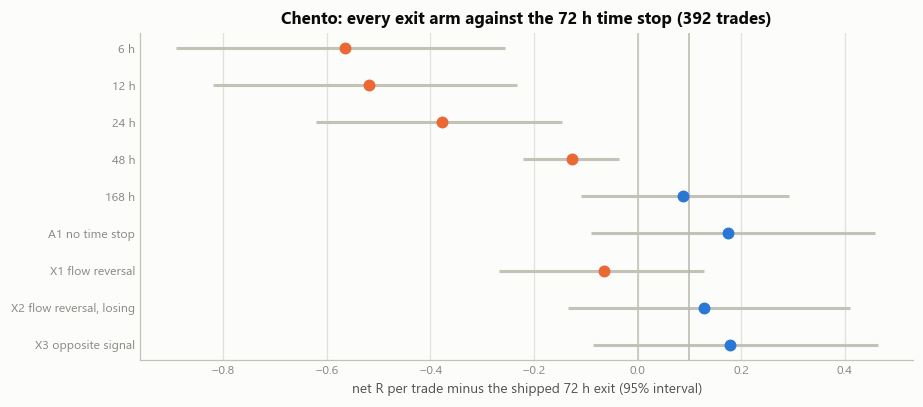

In [4]:
rows = []
for arm, s in REP["by_arm"].items():
    c = REP["candidates"].get(arm)
    rows.append({"arm": arm, "mean_net_R": s["mean_net_R"], "mean_d_vs_A0": c["mean_d"] if c else 0.0,
                 "ci95_lo": c["ci95"][0] if c else None, "ci95_hi": c["ci95"][2] if c else None,
                 "holm_p": V["clauses"][arm]["holm_p"] if c else None, "d_BTC": c["mean_d_BTC"] if c else None,
                 "d_ETH": c["mean_d_ETH"] if c else None, "d_first_half": c["mean_d_first_half"] if c else None,
                 "d_second_half": c["mean_d_second_half"] if c else None, "median_hours_held": s["median_hours_held"],
                 "exit_mix": s["exit_mix"]})
T = pd.DataFrame(rows).set_index("arm")
display(T.round(3))
arms = [a for a in C.CANDIDATES]
fig, ax = plt.subplots(figsize=(8.5, 3.8))
y = np.arange(len(arms))[::-1]
for yi, a in zip(y, arms):
    c = REP["candidates"][a]
    ax.hlines(yi, c["ci95"][0], c["ci95"][2], color=AXIS, linewidth=2)
    ax.scatter([c["mean_d"]], [yi], color=SERIES[0] if c["mean_d"] >= 0 else SERIES[1], s=46, zorder=3)
ax.axvline(0, color=AXIS, linewidth=1); ax.axvline(C.EFFECT_R, color=NEUTRAL, linewidth=1)
ax.set_yticks(y); ax.set_yticklabels(["6 h", "12 h", "24 h", "48 h", "168 h", "A1 no time stop", "X1 flow reversal",
                                      "X2 flow reversal, losing", "X3 opposite signal"], fontsize=8)
style(ax, grid_axis="x"); ax.set_xlabel("net R per trade minus the shipped 72 h exit (95% interval)")
ax.set_title("Chento: every exit arm against the 72 h time stop (392 trades)")
plt.tight_layout(); plt.show()

## 4. The frozen decision

A candidate needs all four: effect ≥ +0.10 R, Holm-adjusted p ≤ 0.05, positive on both assets and in both halves, and
support from walk-forward re-selection. None passes; the walk-forward picks a different arm in each fold.

In [5]:
display(pd.DataFrame(V["clauses"]).T)
print("walk-forward stitched out-of-sample mean difference:", round(REP["walk_forward"]["stitched_oos_mean_d"], 3))
display(pd.DataFrame(REP["walk_forward"]["folds"])[["oos_start", "oos_end", "selected", "oos_trades"]])
print("VERDICT:", V["verdict"], "| hypothesis 'time stop is harmful':", V["hypothesis_time_stop_harmful"])

,D1_effect,D2_holm,D3_stability,D4_walk_forward,holm_p,passes
A2_6,False,False,False,False,1.0,False
A2_12,False,False,False,False,1.0,False
A2_24,False,False,False,False,1.0,False
A2_48,False,False,False,False,1.0,False
A2_168,False,False,True,False,1.0,False
A1,True,False,False,False,0.935906,False
X1,False,False,False,False,1.0,False
X2,True,False,False,False,1.0,False
X3,True,False,False,False,0.935906,False


walk-forward stitched out-of-sample mean difference: -0.05


,oos_start,oos_end,selected,oos_trades
0,2023-04-17,2024-04-16,A1,75
1,2024-04-16,2025-04-16,X3,59
2,2025-04-16,2026-04-16,A0,90
3,2026-04-16,2027-04-16,X1,34


VERDICT: INCONCLUSIVE | hypothesis 'time stop is harmful': not settled


## 5. Why: the move keeps building for about a week, and holding paid only in 2021–2023

With no exit at all, the average move in the trade's favour grows until about 7 days, half of it by 72 h. The trades the
time stop closes were +1.40 R on average at 72 h; held, 57 reached the target and 77 were stopped out, and the net gain
per such trade was +1.00 R in 2021–2023 and −0.05 R in 2024–2026.

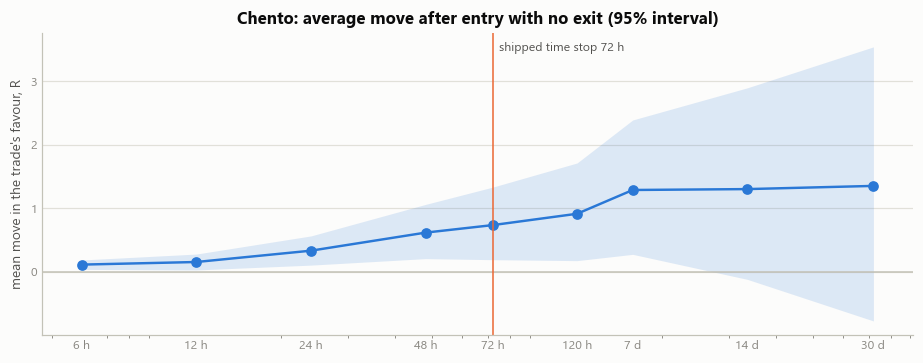

,a1_kind,trades,mean_a0_R,mean_a1_R,sum_d
0,censored_data_end,3,1.012,0.176,-2.507
1,censored_horizon,22,1.477,1.629,3.356
2,stop,77,0.774,-1.053,-140.752
3,target,57,2.243,5.900,208.480


,period,tif_trades,mean_d_on_tif_trades
0,2021-2023,73,1.003
1,2024-2026,86,-0.054


In [6]:
fp = REP["forward_profile"]["by_horizon_h"]
h = np.array([int(k) for k in fp]); m = np.array([fp[k]["mean_R"] for k in fp])
lo = np.array([fp[k]["ci95"][0] for k in fp]); hi = np.array([fp[k]["ci95"][1] for k in fp])
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.fill_between(h, lo, hi, color=SERIES[0], alpha=0.15, linewidth=0)
ax.plot(h, m, marker="o", color=SERIES[0])
ax.axvline(72, color=SERIES[1], linewidth=1)
ax.annotate("shipped time stop 72 h", xy=(72, ax.get_ylim()[1]), xytext=(4, -12), textcoords="offset points", fontsize=8, color=INK2)
ax.set_xscale("log"); ax.set_xticks(h); ax.set_xticklabels([f"{x} h" if x < 168 else f"{x // 24} d" for x in h], fontsize=8)
style(ax); zero_line(ax); ax.set_ylabel("mean move in the trade's favour, R")
ax.set_title("Chento: average move after entry with no exit (95% interval)")
plt.tight_layout(); plt.show()
display(pd.DataFrame(EXP["a0_time_stopped_by_a1_outcome"]))
pd.DataFrame(EXP["a0_time_stopped_by_period"])

## 6. The price of holding longer: drawdown

The bots' own sequence (6 h cooldown, BTC 48 h skip after a losing stop, ETH half risk after a loss, 2% risk, 3× cap), with
drawdown against the fixed $10,000 as in the 2026-09-14 sizing review (A0 reproduces its 33% / 21%).

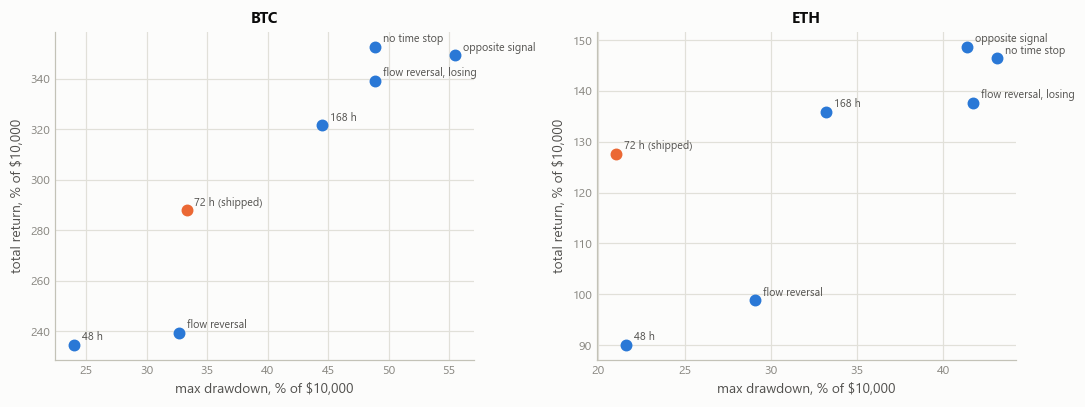

,BTC return %,ETH return %,BTC max DD %,ETH max DD %
A0,287.9,127.6,33.3,21.0
A2_48,234.8,90.1,24.0,21.6
A2_168,321.7,135.9,44.5,33.2
A1,352.6,146.4,48.9,43.1
X1,239.5,98.8,32.7,29.1
X2,339.4,137.6,48.9,41.8
X3,349.3,148.6,55.5,41.4


In [7]:
seq = EXP["fixed_capital_sequence"]
labels = {"A0": "72 h (shipped)", "A2_48": "48 h", "A2_168": "168 h", "A1": "no time stop", "X1": "flow reversal",
          "X2": "flow reversal, losing", "X3": "opposite signal"}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, asset in zip(axes, ("BTC", "ETH")):
    for i, (arm, lab) in enumerate(labels.items()):
        s = seq[arm][asset]
        ax.scatter(s["max_drawdown_pct_of_capital"], s["total_return_pct_of_capital"], s=46,
                   color=SERIES[1] if arm == "A0" else SERIES[0], zorder=3)
        ax.annotate(lab, (s["max_drawdown_pct_of_capital"], s["total_return_pct_of_capital"]), xytext=(5, 3),
                    textcoords="offset points", fontsize=7, color=INK2)
    style(ax, grid_axis="both"); ax.set_title(asset, fontsize=10)
    ax.set_xlabel("max drawdown, % of $10,000"); ax.set_ylabel("total return, % of $10,000")
plt.tight_layout(); plt.show()
pd.DataFrame({arm: {f"{a} return %": round(seq[arm][a]["total_return_pct_of_capital"], 1) for a in ("BTC", "ETH")}
              | {f"{a} max DD %": round(seq[arm][a]["max_drawdown_pct_of_capital"], 1) for a in ("BTC", "ETH")} for arm in labels}).T

## Conclusion

- **Keep 72 h.** Every shorter time stop is significantly worse, and no alternative passed the frozen rule.
- **No time stop** is ahead on average (+0.18 R per trade) but not reliably: all of it came from 2021–2023, and it costs
  much more drawdown (ETH 21% → 43%). Settling it needs data after 2026-09-11, for example a paper twin of chento without
  the time stop running beside the shipped bot, plus an exposure budget.
- **"Exit when shown wrong"** did not help: a flow reversal cuts winners, and the opposite chento signal almost never fires
  during a trade. The structural stop remains the only invalidation that does not damage the payoff.